<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Extracurricular topics

This notebook is not part of the curriculum but shows some more advanced concepts about waveform generation.
Read and play with it if you have time.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/02_Signal_Processing/Extracurricular_topics.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
! pip install -q PyCBC==2.10.0 lalsuite==7.25 cryptography==43.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 12.2 MB/s eta 0:00:00


## Initialization

In [3]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [4]:
from pycbc.waveform import get_td_waveform, get_fd_waveform

## More realistic waveforms

In previous sections, we were using spins aligned with the orbital angular momentum, without higher harmonics, no spin precession and no eccentricity. Here we want to try to visualize how these other physical effects impact the morphology of the gravitational wave signals.

First, we add **higher harmonics**. The full gravitational signal for all directions of emission $(\theta,\phi)$ in the source frame can be decomposed in spin-weighted spherical harmonics as

$$ h_+ - i h_\times  = \sum_{\ell \geq2} \sum_{m=-\ell}^{+\ell} {}_{-2}Y_{\ell m}(\theta, \phi) h_{\ell m}$$

The harmonics $h_{22},h_{2,-2}$ are dominant, but the subdominant harmonics can bring important corrections to the waveform, particularly at merger, for high inclination and high mass ratio. We use here the model `IMRPhenomTHM` ([article](https://arxiv.org/abs/2012.11923))

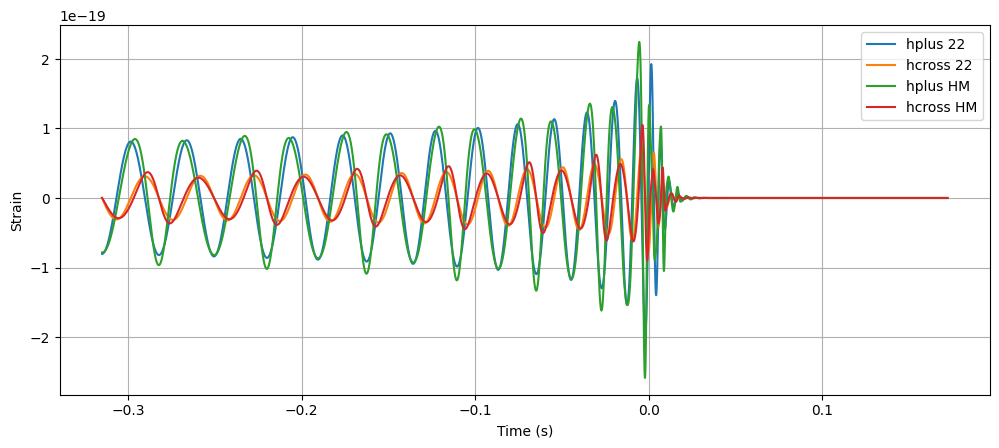

In [5]:
hp_22, hc_22 = get_td_waveform(approximant="IMRPhenomT",
                         mass1=60,
                         mass2=10,
                         inclination=np.pi/2 - 0.2,
                         delta_t=1.0/16384,
                         f_lower=30)

hp_hm, hc_hm = get_td_waveform(approximant="IMRPhenomTHM",
                         mass1=60,
                         mass2=10,
                         inclination=np.pi/2 - 0.2,
                         delta_t=1.0/16384,
                         f_lower=30)
times = hp_22.sample_times

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(times, hp_22, label='hplus 22')
plt.plot(times, hc_22, label='hcross 22')
plt.plot(times, hp_hm, label='hplus HM')
plt.plot(times, hc_hm, label='hcross HM')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()

Next, we add **spin precession** : when at least one of the black hole spins is misaligned from the orbital angular momentum, both the spins and the normal to the orbital plane will precess, leading to modulations in the observed signal. This effect is largest for high spins, high mass ratio and high inclination. Here we use the `IMRPhenomTPHM` model ([article](https://arxiv.org/abs/2105.05872)).

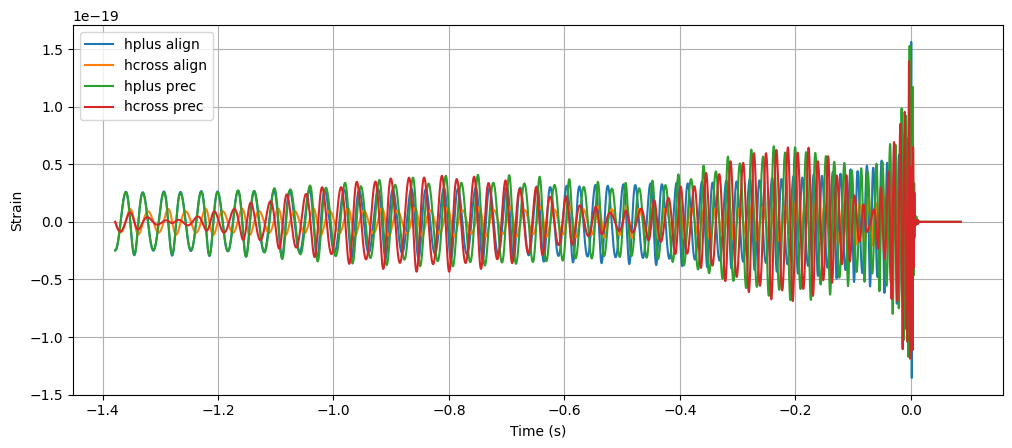

In [6]:
hp_align, hc_align = get_td_waveform(approximant="IMRPhenomTPHM",
                         mass1=30,
                         mass2=5,
                         spin1x=0.,
                         inclination=np.pi/2 - 0.2,
                         delta_t=1.0/16384,
                         f_lower=30)

hp_prec, hc_prec = get_td_waveform(approximant="IMRPhenomTPHM",
                         mass1=30,
                         mass2=5,
                         spin1x=0.8,
                         inclination=np.pi/2 - 0.2,
                         delta_t=1.0/16384,
                         f_lower=30)
times_align = hp_align.sample_times
times_prec = hp_prec.sample_times

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(times_align, hp_align, label='hplus align')
plt.plot(times_align, hc_align, label='hcross align')
plt.plot(times_prec, hp_prec, label='hplus prec')
plt.plot(times_prec, hc_prec, label='hcross prec')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()

What about **eccentricity** ? Waveform modelers are working hard to build accurate waveform models for the eccentric case, but they are not yet available via PyCBC waveform generation... this will be added to these tutorials in the near future. You can find recent examples of waveform models for eccentric waveforms in the papers for `SEOBNRv5EHM` ([article](https://arxiv.org/abs/2412.12823)) and `IMRPhenomTEHM` ([article](https://arxiv.org/abs/2503.13062)).

## Time-to-frequency correspondence for chirping signals

The frequency evolution at leading order in the post-Newtonian expansion, using the quadrupole formula for the emission of gravitational waves and the energy/flux balance equation, is:

$$ \dot{\phi}_{\rm orb} (t) = \omega_{\rm orb}(t) = \left[ \frac{256}{5} \left(\frac{G \mathcal{M}_c}{c^3}\right)^{5/3} (t_c - t) \right]^{-3/8} $$

where $\mathcal{M}_c = (m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$ is the chirp mass, and $\phi_{\rm orb}$ is the orbital phase. $t_c$ is the time to coalescence; this simplified relation should not be used to close to the coalescence itself where it loses accuracy and diverges. This describes the chirp in frequency, far from the coalescence.

The frequency of the dominant 22 harmonic is then:

$$ \omega_{22}(t) = 2\omega_{\rm orb}(t) = 2\pi f_{22}(t) $$

This relation is very useful to estimate how long the signals are, for a given chirp mass and starting frequency; or conversely, what is their starting frequency for a given length of the signal.

We will illustrate this approximate chirp relation below. First, we generate a waveform with zero inclination (and only the 22-mode), a trick that allows us to read the phase evolution directly off the phase of $h_+ - i h_\times \propto e^{-2 i \phi_{\rm orb}}$.

In [7]:
m1 = 25.
m2 = 20.

hp, hc = get_td_waveform(approximant="IMRPhenomT",
                         mass1=m1,
                         mass2=m2,
                         inclination=0.,
                         delta_t=1.0/16384,
                         f_lower=30)

times = hp.sample_times
phi_22 = np.unwrap(np.angle(hp - 1j*hc))

We then compute the derivate numerically, using a cubic spline interpolant ([link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.InterpolatedUnivariateSpline.html) to the interface):

In [8]:
from scipy.interpolate import InterpolatedUnivariateSpline as spline

# Build the spline interpolant
spline_phi_22 = spline(times, phi_22)

# This syntax gives the first derivative at the desired time
omega_22 = spline_phi_22(times, 1)

f_22 = -omega_22 / (2*np.pi)

We can then plot the evolution of $\omega_{22}(t)$ (flipping the sign, as it is negative); we see distinctly that the frequency increases rapidly at merger, before saturating to the ringdown frequency. We then overlay the approximate estimate given by the power-law formula above (we need the solar mass expressed in seconds, $G M_\odot/c^3$, taken from LAL).

In [9]:
import lal

# G Msol/c^3, in seconds
lal.MTSUN_SI

4.925490947641267e-06

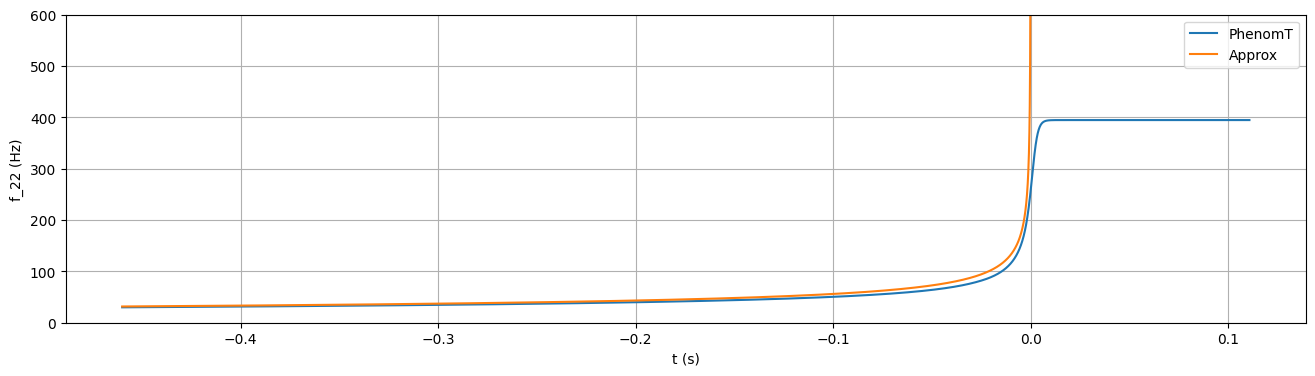

In [10]:
Mchirp = (m1*m2)**(3./5) / (m1+m2)**(1./5)
Mchirp_s = Mchirp * lal.MTSUN_SI

tc = 0.
mask = (times < tc)
omega_22_approx = 2 * (256/5 * (tc - times[mask]) * Mchirp_s**(5/3.))**(-3./8)
f_22_approx = omega_22_approx / (2*np.pi)

fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(times, f_22, label='PhenomT')
ax.plot(times[mask], f_22_approx, label='Approx')
ax.set_ylim(0., 600.)
ax.set_xlabel('t (s)')
ax.set_ylabel('f_22 (Hz)')
ax.legend()
ax.grid()

We can use the above approximate relation to get a sense of the **time-to-frequency correspondence**: looking at the waveform in the Fourier domain, what part of the waveform correspond to what time-to-merger ? The mapping is direct (for a single harmonic $h_{\ell m}$) during the inspiral phase, while things get less clear after the merger: qualitatively, a transient signal in time domain has a broad spectrum in Fourier domain.

We can also take directly the time-domain $\omega_{22}(t)$, extract the merger frequency and the ringdown frequency of the 22 mode and represent those points atop the Fourier domain waveform:

In [11]:
# The merger is at t=0 by convention
t_merger = 0.

f_merger = -spline_phi_22(t_merger, 1) / (2*np.pi)

# For the ringdown frequency, we take any time long enough after merger
t_ringdown = 0.05

f_ringdown = -spline_phi_22(t_ringdown, 1) / (2*np.pi)

# This is chosen at t=-0.1s for illustration
t_m01s = -0.1

f_m01s = -spline_phi_22(t_m01s, 1) / (2*np.pi)

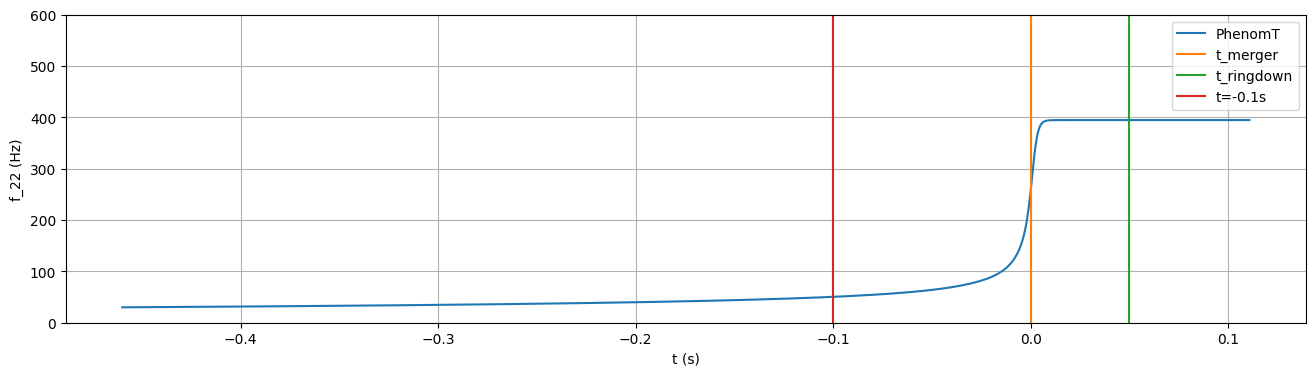

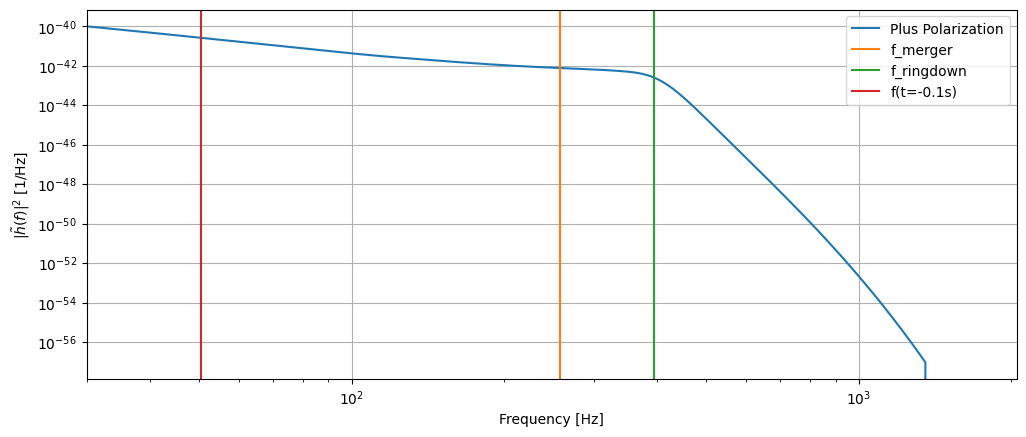

In [12]:
hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXAS",
                         mass1=m1,
                         mass2=m2,
                         f_lower=30,
                         inclination=np.pi/3,
                         delta_f=1./8)

fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(times, f_22, label='PhenomT')
plt.axvline(t_merger, label='t_merger', color='C1')
plt.axvline(t_ringdown, label='t_ringdown', color='C2')
plt.axvline(t_m01s, label='t=-0.1s', color='C3')
ax.set_ylim(0., 600.)
ax.set_xlabel('t (s)')
ax.set_ylabel('f_22 (Hz)')
ax.legend()
ax.grid()

plt.figure(figsize=plt.figaspect(0.4))
plt.loglog(hp_fd.sample_frequencies, hp_fd.squared_norm(), label='Plus Polarization')
plt.axvline(f_merger, label='f_merger', color='C1')
plt.axvline(f_ringdown, label='f_ringdown', color='C2')
plt.axvline(f_m01s, label='f(t=-0.1s)', color='C3')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|^2$ [1/Hz]')
plt.xlim([30,2048])
plt.legend()
plt.grid()

This gives us a sense of what happens in the Fourier domain: the inspiral is a slow, long process where the frequency increases little by little. In fact, this is the reason why the Fourier-domain amplitude appears to be decreasing: the systems spends a lot of time emitting at these frequencies. When approaching merger, the frequency starts increasing much more rapidly and the signal sweeps quickly through the frequency band.

## Going further

Consider the following systems: a binary black hole system like GW150914, a binary neutron star merger like GW170817. Look up the [GWTC-1](https://gwosc.org/GWTC-1/) catalog page to obtain the estimated masses for these sources.

- Using the approximate relation between time and frequency, what is their time-to-merger starting from 30Hz (starting frequency for early detections), 10Hz (target of current detectors when fully upgraded), and 5Hz (target of future detectors like Einstein Telescope) ? What about a starting frequency of 20mHz, all the way back in the frequency band of the future spatial instrument LISA ?

The binary black hole system GW150914 merges very rapidly after entering the ground-based detector band, reaching merger in less than a second from 30 Hz. In contrast, the binary neutron star system GW170817 remains in band for nearly a minute from 30 Hz and for centuries from 20 mHz, demonstrating why low-frequency detectors such as LISA can observe compact binaries long before merger.

In [14]:
# Going Further: Compare time-to-merger for GW150914 and GW170817
# starting from 30 Hz, 10 Hz, 5 Hz, and 20 mHz (0.02 Hz)

import numpy as np
import lal

# Solar mass in time units: G*M_sun/c^3 (seconds)
MTSUN = lal.MTSUN_SI

def chirp_mass(m1, m2):
    """
    Compute chirp mass in solar masses.
    """
    return (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

def time_to_merger(f, m1, m2):
    """
    Newtonian inspiral time remaining until merger
    from gravitational-wave frequency f (Hz).
    Returns time in seconds.
    """
    Mc = chirp_mass(m1, m2) * MTSUN  # convert to seconds
    return (5.0 / 256.0) * (np.pi * f)**(-8.0/3.0) * Mc**(-5.0/3.0)

def format_time(seconds):
    """
    Convert seconds into human-readable form.
    """
    if seconds < 60:
        return f"{seconds:.2f} s"
    elif seconds < 3600:
        return f"{seconds/60:.2f} min"
    elif seconds < 86400:
        return f"{seconds/3600:.2f} hr"
    elif seconds < 365.25 * 86400:
        return f"{seconds/86400:.2f} days"
    else:
        return f"{seconds/(365.25*86400):.2f} years"

# Source masses from GWTC-1
systems = {
    "GW150914 (Binary Black Hole)": (36.2, 29.1),
    "GW170817 (Binary Neutron Star)": (1.46, 1.27),
}

# Starting frequencies
frequencies = [30, 10, 5, 0.02]  # Hz

for name, (m1, m2) in systems.items():
    print("=" * 70)
    print(name)
    print(f"m1 = {m1:.2f} Msun, m2 = {m2:.2f} Msun")
    print(f"Chirp mass = {chirp_mass(m1, m2):.3f} Msun\n")

    for f in frequencies:
        t = time_to_merger(f, m1, m2)
        print(f"Time to merger from {f:>6g} Hz : {format_time(t)}")

    print()

GW150914 (Binary Black Hole)
m1 = 36.20 Msun, m2 = 29.10 Msun
Chirp mass = 28.221 Msun

Time to merger from     30 Hz : 0.28 s
Time to merger from     10 Hz : 5.33 s
Time to merger from      5 Hz : 33.83 s
Time to merger from   0.02 Hz : 2.66 years

GW170817 (Binary Neutron Star)
m1 = 1.46 Msun, m2 = 1.27 Msun
Chirp mass = 1.185 Msun

Time to merger from     30 Hz : 56.12 s
Time to merger from     10 Hz : 17.51 min
Time to merger from      5 Hz : 1.85 hr
Time to merger from   0.02 Hz : 524.36 years

